# **XGBoost**

Notebooks 01-03 built the dataset and set the bar. Under 10-window cross-validation the best
statistical baseline was SARIMA at 14.46 MAE, ahead of Seasonal Naive Daily at 15.50.

This notebook builds the model that has to beat them.

---
## **01 - Setup and data**

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# Spanish national holidays behave like Sundays in the demand profile.
# If the package is missing the notebook still runs, with the flag at 0.
try:
    import holidays as holidays_pkg
    HOLIDAYS_AVAILABLE = True
except ImportError:
    HOLIDAYS_AVAILABLE = False
    print("`holidays` not installed -> is_holiday will be all zeros. Run: pip install holidays")

plt.style.use("fivethirtyeight")
BLUE, ORANGE, DARKBLUE, GREEN, GREY = "#378ADD", "#D85A30", "#1D5FA5", "#639922", "#888780"

In [2]:
from src.paths import DATA_PROCESSED, MODELS_DIR

df = pd.read_csv(DATA_PROCESSED / "spain_day_ahead_hourly_2022_2026_madrid_time.csv",
                 parse_dates=["datetime"])

TARGET    = "price_eur_mwh"
HORIZON   = 24    # the auction clears 24 hours at once

RANDOM_STATE = 42

df = df.set_index("datetime").sort_index()
df = df[~df.index.duplicated(keep="first")]

# asfreq("h") makes the hourly grid explicit: a missing timestamp becomes a NaN row
# instead of an invisible hole. .shift() counts positions, not clock time, so a hole
# would misalign every lag after it.
df = df.asfreq("h")

print(f"rows          : {len(df):,}")
print(f"range         : {df.index[0]}  ->  {df.index[-1]}")
print(f"missing hours : {df[TARGET].isna().sum()}")
df.head()

rows          : 33,936
range         : 2022-10-01 00:00:00  ->  2026-08-14 23:00:00
missing hours : 4


,price_eur_mwh
datetime,
2022-10-01 00:00:00,167.00
2022-10-01 01:00:00,103.80
2022-10-01 02:00:00,90.56
2022-10-01 03:00:00,85.00
2022-10-01 04:00:00,79.22


## **02 - Preventing data leakage**

**What we're predicting:** this project forecasts the day-ahead electricity prices for all 24 hours
of the next day (Day D+1), using only information available today (Day D).

**The 24-hour shift.**

When we use past prices (called 'lagged features') to predict future prices, we need a 'fixed offset' (how far back in time we look). If this offset is too small (e.g., 1 hour), predicting the last hour of tomorrow (D+1 23:00) would require knowing the price from D+1 22:00, a future price that isn't known yet.

To ensure all historical prices used are truly from the past, every price-derived feature must be 'shifted' by at least **24 hours**. This guarantees that all inputs to our model come from Day D or earlier. Which reflects how the electricity auction clears.

---
## **03 - Feature engineering**

### **3.1 - Evidence for the lag choices**

The autocorrelation function shows how strongly the price at hour *t* relates to the price *k* hours
earlier, for every *k*. It is the most direct justification for which lags to include.

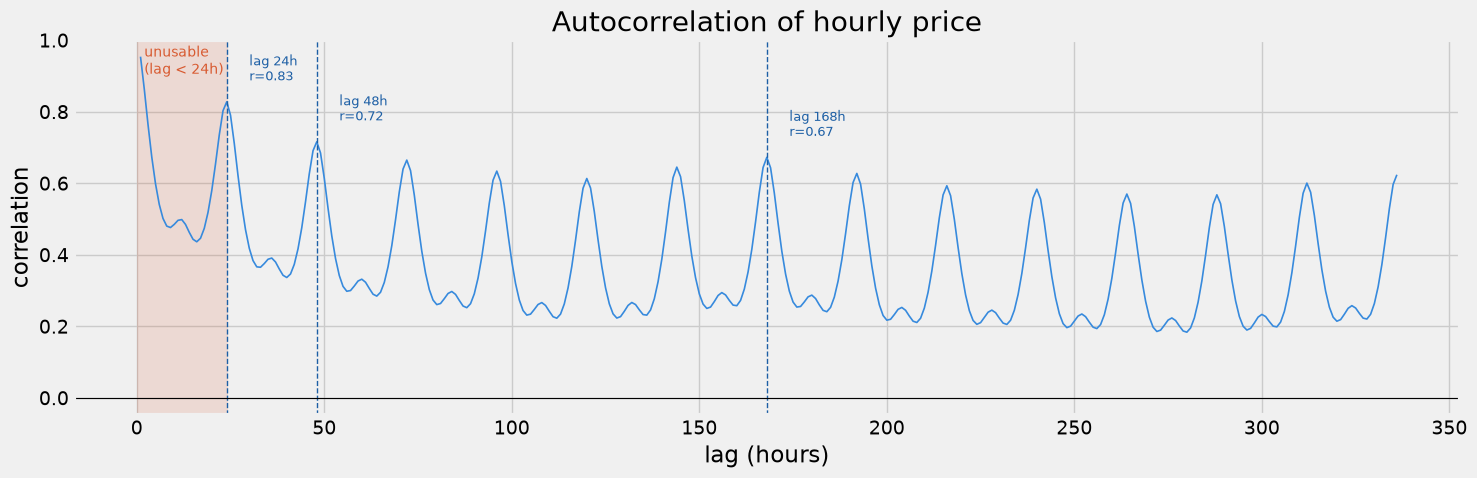

24     0.827
48     0.716
72     0.664
168    0.672


In [3]:
MAX_LAG = 24 * 14   # 336 hours
acf = pd.Series([df[TARGET].autocorr(lag=k) for k in range(1, MAX_LAG + 1)],
                index=range(1, MAX_LAG + 1))

fig, ax = plt.subplots(figsize=(15, 5))
ax.axvspan(0, 24, color=ORANGE, alpha=0.15)
ax.text(2, acf.max() * 0.95, "unusable\n(lag < 24h)", fontsize=10, color=ORANGE)
ax.plot(acf.index, acf.values, lw=1.2, color=BLUE)

for lag in [24, 48, 168]:
    ax.axvline(lag, color=DARKBLUE, ls="--", lw=1)
    ax.annotate(f"lag {lag}h\nr={acf[lag]:.2f}", xy=(lag, acf[lag]),
                xytext=(lag + 6, acf[lag] + 0.06), fontsize=9, color=DARKBLUE)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Autocorrelation of hourly price")
ax.set_xlabel("lag (hours)"); ax.set_ylabel("correlation")
plt.tight_layout(); plt.show()

print(acf.loc[[24, 48, 72, 168]].round(3).to_string())

The ACF has a sharp local maximum at every multiple of 24 and a distinct one at 168.
`lag_24h`, `lag_48h` and `lag_168h` are the three lags kept. The shaded region is unusable for a
D+1 forecast regardless of how informative it looks.

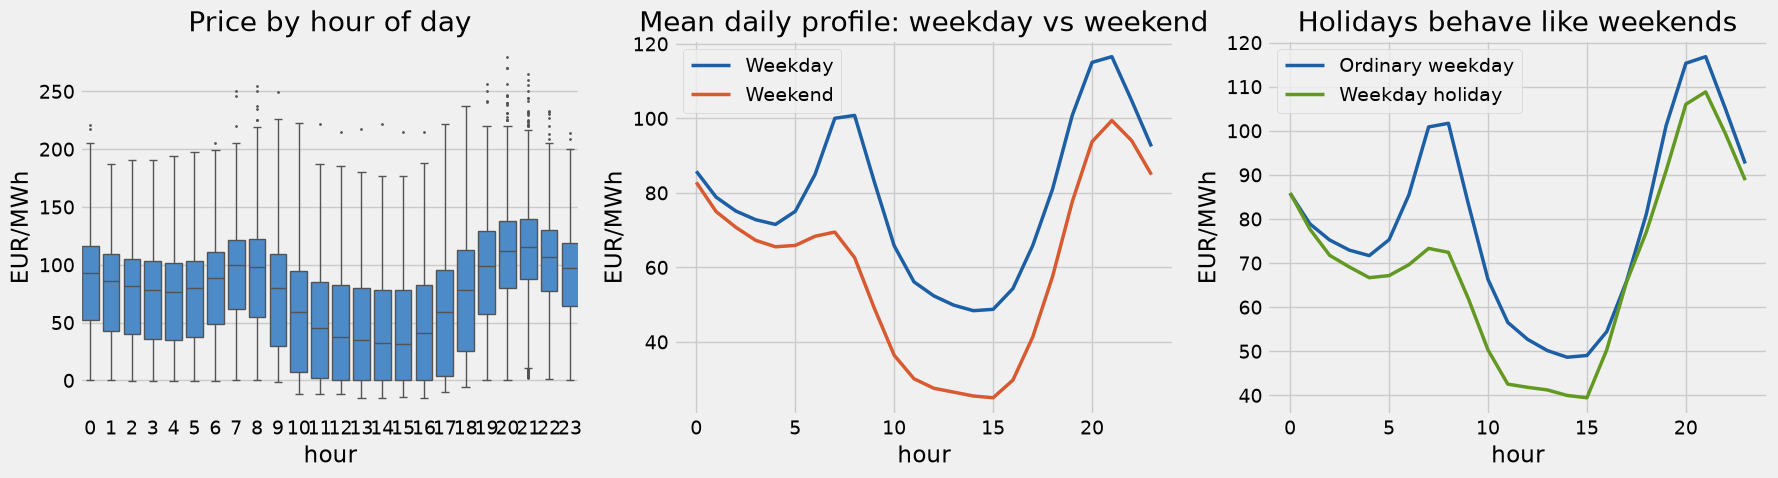

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df.index.hour, y=df[TARGET], ax=axes[0], color=BLUE, fliersize=1)
axes[0].set_title("Price by hour of day")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("EUR/MWh")

profile = df.groupby([df.index.dayofweek >= 5, df.index.hour])[TARGET].mean().unstack(0)
profile.columns = ["Weekday", "Weekend"]
profile.plot(ax=axes[1], lw=2.5, color=[DARKBLUE, ORANGE])
axes[1].set_title("Mean daily profile: weekday vs weekend")
axes[1].set_xlabel("hour"); axes[1].set_ylabel("EUR/MWh")

if HOLIDAYS_AVAILABLE:
    es     = holidays_pkg.country_holidays("ES", years=range(df.index.year.min(), df.index.year.max() + 1))
    is_hol = pd.Series(df.index.date, index=df.index).isin(set(es)).values
    is_wd  = df.index.dayofweek < 5
    comp = pd.DataFrame({
        "Ordinary weekday": df[TARGET][is_wd & ~is_hol].groupby(df.index[is_wd & ~is_hol].hour).mean(),
        "Weekday holiday":  df[TARGET][is_wd &  is_hol].groupby(df.index[is_wd &  is_hol].hour).mean()})
    comp.plot(ax=axes[2], lw=2.5, color=[DARKBLUE, GREEN])
    axes[2].set_title("Holidays behave like weekends")
    axes[2].set_xlabel("hour"); axes[2].set_ylabel("EUR/MWh")

plt.tight_layout(); plt.show()

Hour is the dominant driver. Weekend shifts the whole profile down and flattens the evening peak, which is a level and a shape effect, so `day_of_week` and `is_weekend` both earn their place.
Holidays track the weekend profile on days the calendar calls weekdays, which no other feature can express.


### **3.2 - Calendar features**

In [5]:
def create_calendar_features(data):

    """Features from the timestamp alone. These are the only ones knowable in advance,
    which is what lets us build a design matrix for a day that has not happened yet."""

    d = data.copy()

    d["hour"]        = d.index.hour
    d["day_of_week"] = d.index.dayofweek          # 0 = Monday
    d["month"]       = d.index.month
    d["is_weekend"]  = (d.index.dayofweek >= 5).astype(int)

    if HOLIDAYS_AVAILABLE:
        es = holidays_pkg.country_holidays(
            "ES", years=range(d.index.year.min(), d.index.year.max() + 1))
        d["is_holiday"] = pd.Series(d.index.date, index=d.index).isin(set(es)).astype(int)
    else:
        d["is_holiday"] = 0

    # circular encodings: keep 23h next to 00h, and December next to January
    d["hour_sin"]  = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"]  = np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)

    return d

### **3.3 - Price features**

Three lags + one rolling aggregate.

`lag_24h`, `lag_48h`, `lag_168h` are the same hour yesterday, the day before, and last week.

`same_hour_mean_7d` is the mean of that same hour over the last 7 days. A single lag is one noisy
observation, so an unusual day propagates straight into the forecast. Averaging seven of them gives a
de-noised daily profile.

In [6]:
def create_price_features(data, target=TARGET):
    d = data.copy()
    y = d[target]

    d["lag_24h"]  = y.shift(24)      # same hour, day D
    d["lag_48h"]  = y.shift(48)      # same hour, day D-1
    d["lag_168h"] = y.shift(168)     # same hour, last week

    # base = y.shift(MIN_SHIFT)

    # mean of THIS hour over the last 7 days. Grouping by hour makes each rolling
    # step one day instead of one hour.
    d["same_hour_mean_7d"] = (y.shift(24).groupby(d.index.hour)
                                  .transform(lambda s: s.rolling(7, min_periods=7).mean()))
    return d

In [7]:
CALENDAR_FEATURES = ["hour", "hour_sin", "hour_cos",
                     "day_of_week", "is_weekend", "is_holiday",
                     "month", "month_sin", "month_cos"]
LAG_FEATURES      = ["lag_24h", "lag_48h", "lag_168h"]
ROLLING_FEATURES  = ["same_hour_mean_7d"]

FEATURES = CALENDAR_FEATURES + LAG_FEATURES + ROLLING_FEATURES


def create_features(data):
    """Raw price frame -> frame with all features.

    One function for training, cross-validation and live forecasting. A transformation
    that exists in only one of those paths is a training/serving skew bug."""
    return create_price_features(create_calendar_features(data))


print(f"{len(FEATURES)} features")

13 features


In [10]:
# The longest window is 7 days on top of a 24h shift and reaches back to t-168, so the
# first 7 days cannot have complete features. They are dropped rather than filled:
# imputing would invent price history that never existed.

model_df = create_features(df).dropna(subset=FEATURES + [TARGET]).copy()

print(f"raw rows    : {len(df):,}")
print(f"usable rows : {len(model_df):,}   (dropped {len(df) - len(model_df)} warm-up hours)")
print(f"first usable: {model_df.index.min()}")
model_df[FEATURES].describe().T.round(2)

raw rows    : 33,936
usable rows : 33,736   (dropped 200 warm-up hours)
first usable: 2022-10-08 00:00:00


,count,mean,std,min,25%,50%,75%,max
hour,33736.0,11.51,6.92,0.00,6.00,12.00,18.00,23.00
hour_sin,33736.0,-0.00,0.71,-1.00,-0.71,0.00,0.71,1.00
hour_cos,33736.0,-0.00,0.71,-1.00,-0.71,-0.00,0.71,1.00
day_of_week,33736.0,3.00,2.00,0.00,1.00,3.00,5.00,6.00
is_weekend,33736.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
is_holiday,33736.0,0.02,0.16,0.00,0.00,0.00,0.00,1.00
month,33736.0,6.44,3.48,1.00,3.00,6.00,10.00,12.00
month_sin,33736.0,0.03,0.69,-1.00,-0.50,0.00,0.87,1.00
month_cos,33736.0,0.00,0.72,-1.00,-0.87,0.00,0.87,1.00
lag_24h,33736.0,72.57,49.26,-15.00,29.19,78.93,109.40,270.00


###  **3.4 - Feature correlation**

In [11]:
def feat_corr(input_df):
    corr = input_df.corr()
    plt.figure(figsize=(15,12))
    #plot heat map
    g=sns.heatmap(corr,annot=True,cmap="RdYlGn", vmin=-1, vmax=1)
    plt.title('Feature Correlation')

    return plt.show()

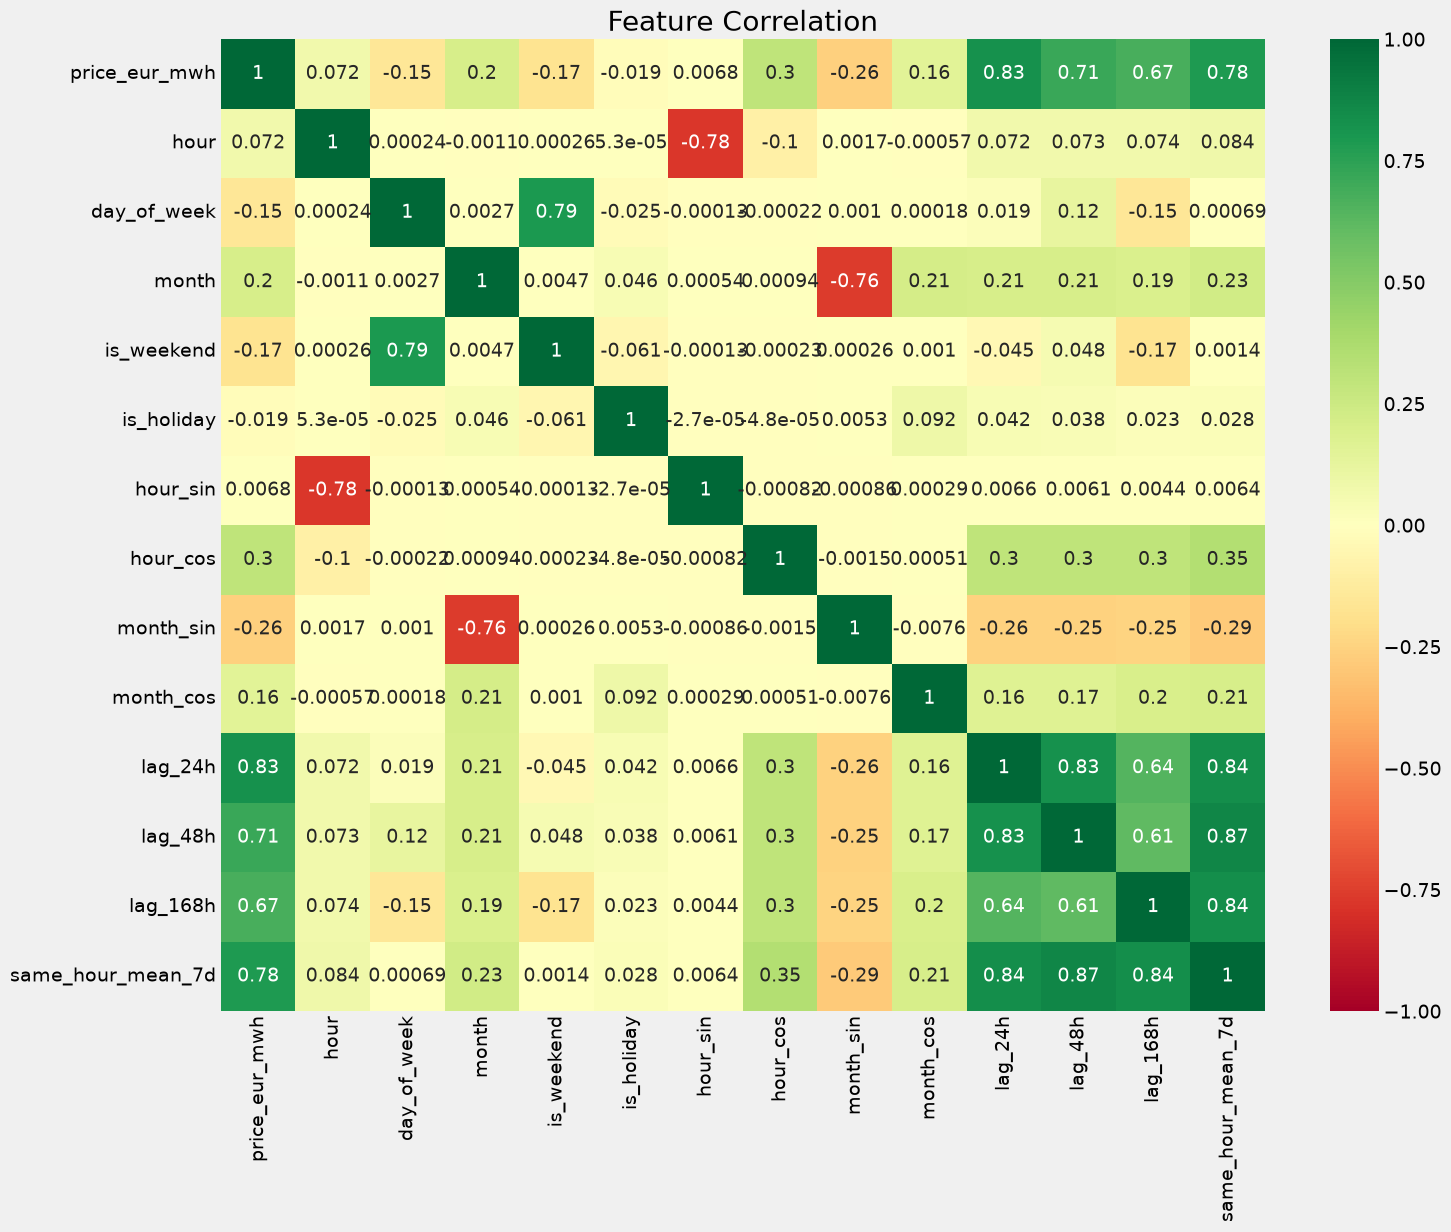

In [12]:
feat_corr(model_df)

We can obseve that there is a very strong correlation between **"price_eur_mwh"** and all of the lag and rolling agregate feature. Which can also seen below in the **Feature Importance** table.

---
## **04 - Cross-validation**

Same protocol as notebook 03 so the numbers are comparable: h = 24, step = 24, 10 non-overlapping
windows ending on the last day of the dataset. Each window predicts one full delivery day and trains
only on data strictly before it.

One difference, stated openly: notebook 03 restricted AutoARIMA to a 60-day training window for
runtime reasons and used `refit=False`. XGBoost trains on all history before each fold and refits
every fold. That means the comparison mixes model class with training window size.

In [13]:
XGB_PARAMS = dict(
    n_estimators  = 600,                # More trees = more capacity
    learning_rate = 0.03,
    max_depth     = 6,                  # Combine up to 6 features
    subsample     = 0.8,                # Each tree can see 80% of the rows at random
    colsample_bytree = 0.8,             # Each tree can see 80% of the columns
    min_child_weight = 5,
    objective     = "reg:squarederror",
    random_state  = RANDOM_STATE,       # So that it is reproducible
    n_jobs        = -1,                 # Uses all jobs
)

In [14]:
def xgb_cross_validation(data, n_windows=10, horizon=HORIZON, features=FEATURES, verbose=True):

    last_day = data.index.max().normalize()
    folds = []

    for k in range(n_windows, 0, -1):
        cutoff     = last_day - pd.Timedelta(days=k)          # last known day
        test_start = cutoff + pd.Timedelta(days=1)            # the delivery day D+1
        test_end   = test_start + pd.Timedelta(hours=horizon - 1)
                                                              # We get 10 consecutive days, with no overlapping
        train = data.loc[data.index < test_start]
        test  = data.loc[test_start:test_end]
        if len(test) < horizon:
            continue

        model = xgb.XGBRegressor(**XGB_PARAMS)
        model.fit(train[features], train[TARGET])             # Trains
        pred = model.predict(test[features])                  # Predicts

        # We save 'y' and 'preds' in a DataFrame with the columns used by statsforecast
        folds.append(pd.DataFrame({
            "unique_id": "Spain_Hourly_Price",
            "ds":        test.index,
            "cutoff":    cutoff + pd.Timedelta(hours=23),     # last known hour = D 23:00
            "y":         test[TARGET].values,
            "XGBoost":   pred}))


        print(f"  {test_start.date()}   MAE {mean_absolute_error(test[TARGET], pred):6.2f}")

    return pd.concat(folds, ignore_index=True)


def score_cv(cv, col="XGBoost"):
    mae = mean_absolute_error(cv["y"], cv[col])
    return {"MAE": mae}

In [15]:
cv_df = xgb_cross_validation(model_df, n_windows=10)
cv_df.head()

  2026-08-05   MAE  23.16
  2026-08-06   MAE  16.92
  2026-08-07   MAE   9.47
  2026-08-08   MAE  12.05
  2026-08-09   MAE   8.72
  2026-08-10   MAE   9.77
  2026-08-11   MAE  12.32
  2026-08-12   MAE  10.90
  2026-08-13   MAE   9.73
  2026-08-14   MAE  12.77


,unique_id,ds,cutoff,y,XGBoost
0,Spain_Hourly_Price,2026-08-05 00:00:00,2026-08-04 23:00:00,183.5275,179.602890
1,Spain_Hourly_Price,2026-08-05 01:00:00,2026-08-04 23:00:00,173.8725,179.742401
2,Spain_Hourly_Price,2026-08-05 02:00:00,2026-08-04 23:00:00,164.7650,178.320587
3,Spain_Hourly_Price,2026-08-05 03:00:00,2026-08-04 23:00:00,164.9675,170.062790
4,Spain_Hourly_Price,2026-08-05 04:00:00,2026-08-04 23:00:00,165.1600,171.706238


In [17]:
mae = score_cv(cv_df)

print(f'XGBoost, 10-window CV: MAE {mae["MAE"]:.2f}')

print("\nBaselines from notebook 03, same 10 windows:")
print("  SARIMA    MAE 14.46")
print("  SN Daily  MAE 15.50")
print("  SN Weekly MAE 18.76")
print("  ARIMA     MAE 37.21")

XGBoost, 10-window CV: MAE 12.58

Baselines from notebook 03, same 10 windows:
  SARIMA    MAE 14.46
  SN Daily  MAE 15.50
  SN Weekly MAE 18.76
  ARIMA     MAE 37.21


---
## **05 - Training the final model**



In [18]:
X_all = model_df[FEATURES]
y_all = model_df[TARGET]

final_model = xgb.XGBRegressor(**XGB_PARAMS)
final_model.fit(X_all, y_all)

print(f"trained on {len(X_all):,} rows, {len(FEATURES)} features")
print(f"through    {model_df.index.max()}")

trained on 33,736 rows, 13 features
through    2026-08-14 23:00:00


### **Feature importance**

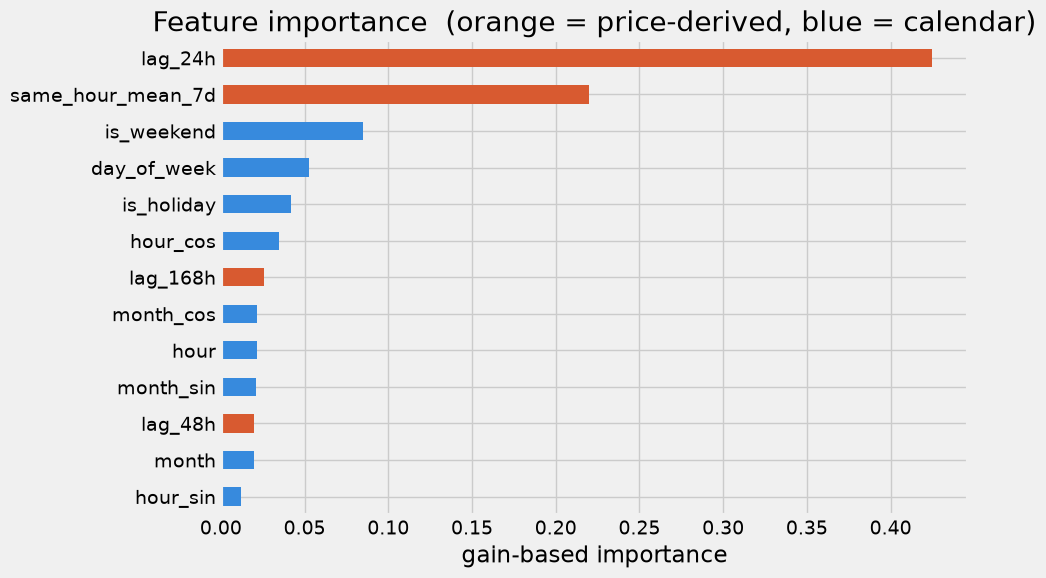

lag_24h              0.4250
same_hour_mean_7d    0.2200
is_weekend           0.0848
day_of_week          0.0524
is_holiday           0.0418
hour_cos             0.0350
lag_168h             0.0255
month_cos            0.0214
hour                 0.0213
month_sin            0.0209
lag_48h              0.0201
month                0.0198
hour_sin             0.0121
dtype: float32

In [19]:


importance = (pd.Series(final_model.feature_importances_,
                        index=final_model.get_booster().feature_names)
                .sort_values())

colors = [ORANGE if f in LAG_FEATURES + ROLLING_FEATURES else BLUE for f in importance.index]

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature importance  (orange = price-derived, blue = calendar)")
ax.set_xlabel("gain-based importance")
plt.tight_layout(); plt.show()

importance.sort_values(ascending=False).round(4)

---
## **06 - Saving the model**


In [20]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)   # git doesn't track empty dirs
final_model.save_model(MODELS_DIR / "xgboost_final.json")
print(f"saved {MODELS_DIR / 'xgboost_final.json'}")

saved C:\Users\pmont\Documents\Projects\e-p-f-pt2\energy_price_forecasting\models\xgboost_final.json


---
## **07 - Using the saved model**


In [21]:

model = xgb.XGBRegressor()
model.load_model(MODELS_DIR / "xgboost_final.json")

FEATURES = model.get_booster().feature_names   # column order comes from the model itself


def forecast_next_day(history, model, features, horizon=HORIZON):
    """Forecast the 24 hours of D+1 in one batch.

    Takes the raw price frame, not the feature matrix: features are rebuilt with the same
    create_features() used in training, so training and serving stay identical."""
    target_day   = history.index.max().normalize() + pd.Timedelta(days=1)
    future_index = pd.date_range(target_day, periods=horizon, freq="h")

    # empty rows for the target day. Calendar features come from the timestamp,
    # price features from the concatenated history.
    future   = pd.DataFrame({TARGET: np.nan}, index=future_index)
    combined = pd.concat([history[[TARGET]], future])

    X = create_features(combined).loc[future_index, features]

    # If this trips, a feature reached into the forecast window: the 24h rule is broken.
    assert X.notna().all().all(), f"NaN in future features: {X.columns[X.isna().any()].tolist()}"

    return pd.DataFrame({"forecast_eur_mwh": model.predict(X)}, index=future_index)


forecast = forecast_next_day(df, model, FEATURES)

print(f"last known day: {df.index.max().normalize().date()}")
print(f"forecast for  : {forecast.index[0].date()}\n")
print(forecast.round(2).to_string())

last known day: 2026-08-14
forecast for  : 2026-08-15

                     forecast_eur_mwh
2026-08-15 00:00:00        168.479996
2026-08-15 01:00:00        165.770004
2026-08-15 02:00:00        162.399994
2026-08-15 03:00:00        159.529999
2026-08-15 04:00:00        154.910004
2026-08-15 05:00:00        152.369995
2026-08-15 06:00:00        149.330002
2026-08-15 07:00:00        143.830002
2026-08-15 08:00:00        130.020004
2026-08-15 09:00:00         98.889999
2026-08-15 10:00:00         40.090000
2026-08-15 11:00:00         17.820000
2026-08-15 12:00:00         13.810000
2026-08-15 13:00:00          7.060000
2026-08-15 14:00:00         16.120001
2026-08-15 15:00:00         16.910000
2026-08-15 16:00:00         29.500000
2026-08-15 17:00:00         73.669998
2026-08-15 18:00:00        107.139999
2026-08-15 19:00:00        140.470001
2026-08-15 20:00:00        186.029999
2026-08-15 21:00:00        189.830002
2026-08-15 22:00:00        185.610001
2026-08-15 23:00:00        168.52

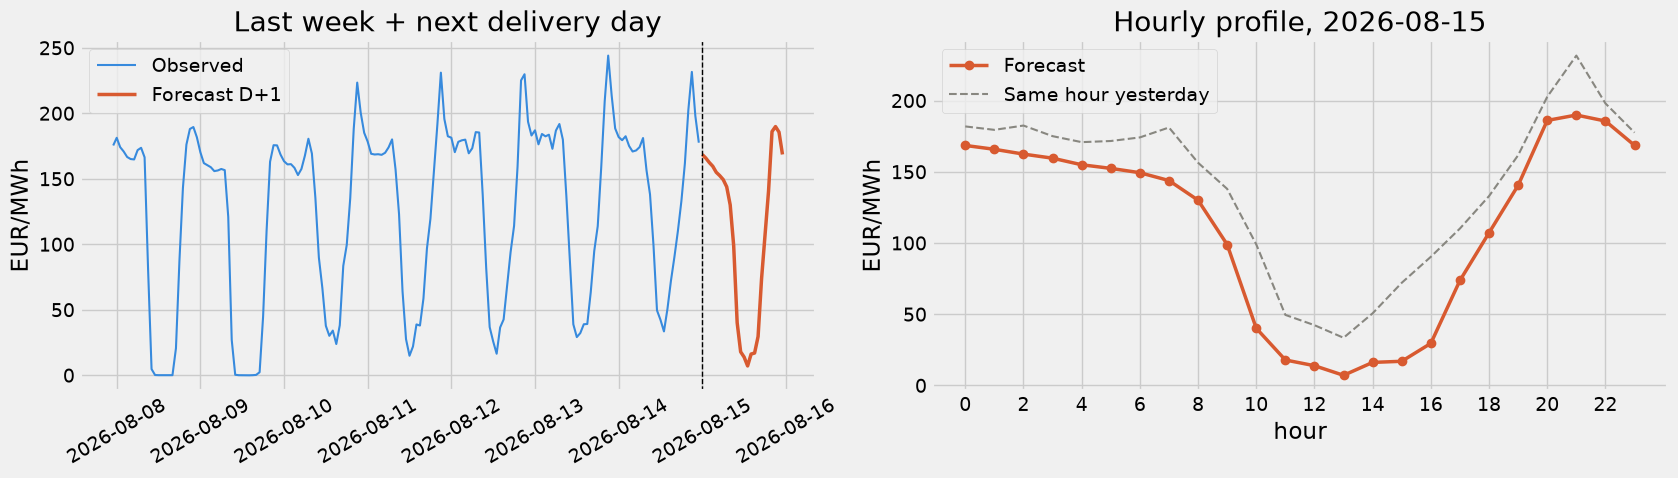

In [22]:
context = df.loc[df.index >= df.index.max() - pd.Timedelta(days=7), TARGET]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].plot(context.index, context.values, lw=1.5, color=BLUE, label="Observed")
axes[0].plot(forecast.index, forecast["forecast_eur_mwh"], lw=2.5, color=ORANGE, label="Forecast D+1")
axes[0].axvline(forecast.index[0], color="black", ls="--", lw=1)
axes[0].set_title("Last week + next delivery day"); axes[0].set_ylabel("EUR/MWh")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(range(24), forecast["forecast_eur_mwh"].values, marker="o", lw=2.5, color=ORANGE,
             label="Forecast")
axes[1].plot(range(24), df[TARGET].iloc[-24:].values, lw=1.5, ls="--", color=GREY,
             label="Same hour yesterday")
axes[1].set_title(f"Hourly profile, {forecast.index[0].date()}")
axes[1].set_xlabel("hour"); axes[1].set_ylabel("EUR/MWh")
axes[1].set_xticks(range(0, 24, 2)); axes[1].legend()

plt.tight_layout(); plt.show()

---
## **Next steps**

* Add exogenous features (weather, energy generation)
* Try to beat xgboost with another model

---

## **Export artifacts for the Streamlit app**

The app must never train, it reads frozen files. This cell only serialises what the
notebook has already computed: no model is refit here and no forecast is recomputed.
`mae`, `rmse` and `mase` are aggregations of the `cv_df` produced by the cross-validation above.

The two data files use the same schema as notebook 03 and this cell appends to them,
so the baselines and XGBoost end up side by side in a single long table. The model the
app loads was already written to `models/` in section 06.

In [23]:
XGB_MODELS = ["XGBoost"]

# --- long format: one row per (timestamp, model) ---
preds = cv_df.melt(id_vars=["ds", "cutoff", "y"], value_vars=XGB_MODELS,
                   var_name="model", value_name="y_pred")

predictions = (preds.rename(columns={"ds": "timestamp", "y": "y_true"})
                    [["timestamp", "model", "y_true", "y_pred"]])

# --- one row of metrics per (model, CV window) ---
# MASE denominator: the MAE of a seasonal-naive (24h) forecast over the history
# strictly before the first test day. Notebook 03 uses the identical definition,
# so the two blocks of cv_metrics.csv are on the same scale and comparable.
insample   = df.loc[df.index < preds["ds"].min(), TARGET]
mase_scale = insample.diff(24).abs().mean()

rows = []
for (model, cutoff), g in preds.groupby(["model", "cutoff"]):
    err = g["y"] - g["y_pred"]
    rows.append({
        "model":  model,
        "window": (cutoff + pd.Timedelta(hours=1)).date(),   # the delivery day, D+1
        "mae":    err.abs().mean(),
        "rmse":   np.sqrt((err ** 2).mean()),
        "mase":   err.abs().mean() / mase_scale,
    })

cv_metrics = pd.DataFrame(rows)

# --- write, appending to what notebook 03 wrote ---
pred_path = DATA_PROCESSED / "predictions.parquet"
met_path  = DATA_PROCESSED / "cv_metrics.csv"

if pred_path.exists():
    old = pd.read_parquet(pred_path)
    # re-running this notebook replaces its own rows instead of duplicating them
    old = old[~old["model"].isin(XGB_MODELS)]
    predictions = pd.concat([old, predictions], ignore_index=True)

if met_path.exists():
    old = pd.read_csv(met_path)
    old = old[~old["model"].isin(XGB_MODELS)]
    cv_metrics = pd.concat([old, cv_metrics], ignore_index=True)

predictions.to_parquet(pred_path, index=False)
cv_metrics.to_csv(met_path, index=False)

print(f"predictions.parquet : {len(predictions):,} rows  |  models: {sorted(predictions['model'].unique())}")
print(f"cv_metrics.csv      : {len(cv_metrics)} rows")

cv_metrics.groupby("model")[["mae", "rmse", "mase"]].mean().round(2)

predictions.parquet : 1,200 rows  |  models: ['ARIMA', 'SARIMA', 'SN Daily', 'SN Weekly', 'XGBoost']
cv_metrics.csv      : 50 rows


,mae,rmse,mase
model,,,
ARIMA,37.21,45.77,1.89
SARIMA,14.46,19.36,0.74
SN Daily,15.50,20.74,0.79
SN Weekly,18.76,24.11,0.95
XGBoost,12.58,16.52,0.64
